# 3CSD Group 8: Advanced SOTA-Oriented GTD Attack Success Model

This notebook is a stronger alternative implementation using **GPU-capable XGBoost with native categorical handling**, expanded leakage-controlled GTD features, validation-based hyperparameter search, validation-optimized decision thresholds, and subgroup error analysis.

Why this is more SOTA-oriented than the baseline notebook:

- It avoids one-hot expansion for high-cardinality categories by using XGBoost's native categorical splits.
- It searches hyperparameters on a temporal validation split.
- It selects the decision threshold from validation data instead of assuming `0.50`.
- It includes more pre-outcome GTD features while still excluding casualties, property damage, ransom, and hostage outcome leakage fields.


## 1. Setup

Set `USE_SAMPLE = True` for a fast classroom check. Final results should use `USE_SAMPLE = False`.


In [1]:
from pathlib import Path
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier

try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
except Exception:
    CUDA_AVAILABLE = False

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MAIN_DATA_PATH = PROJECT_ROOT / "data-raw" / "globalterrorismdb_0522dist.xlsx"
EXTRA_2021_DATA_PATH = PROJECT_ROOT / "data-raw" / "globalterrorismdb_2021Jan-June_1222dist.xlsx"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

USE_SAMPLE = False
SAMPLE_NROWS = 8000
USE_GPU = True
N_SEARCH_TRIALS = 24          # Increase to 40-80 if runtime is acceptable.
THRESHOLD_GRID = np.round(np.arange(0.20, 0.81, 0.01), 2)
RUN_SHAP = True
SHAP_SAMPLE_SIZE = 1500

XGB_DEVICE = "cuda" if USE_GPU and CUDA_AVAILABLE else "cpu"
print("Project root:", PROJECT_ROOT)
print("Main GTD:", MAIN_DATA_PATH)
print("Extra 2021 GTD:", EXTRA_2021_DATA_PATH)
print("CUDA available:", CUDA_AVAILABLE)
print("XGBoost device:", XGB_DEVICE)


Project root: c:\Documents\Compsci\CSELEC2C\Project
Main GTD: c:\Documents\Compsci\CSELEC2C\Project\data-raw\globalterrorismdb_0522dist.xlsx
Extra 2021 GTD: c:\Documents\Compsci\CSELEC2C\Project\data-raw\globalterrorismdb_2021Jan-June_1222dist.xlsx
CUDA available: True
XGBoost device: cuda


## 2. Leakage-Controlled Feature Set

The feature set includes geopolitical, tactical, target, weapon, claim, and coding-quality variables. It excludes post-event consequence variables such as casualties, wounds, property damage, ransom amounts, and hostage outcomes.


In [2]:
ID_COLUMN = "eventid"
TARGET = "success"

NUMERIC_FEATURES = [
    "iyear", "imonth", "iday", "extended", "latitude", "longitude",
    "specificity", "vicinity", "crit1", "crit2", "crit3", "doubtterr",
    "multiple", "suicide", "guncertain1", "guncertain2", "guncertain3",
    "individual", "claimed", "claim2", "claim3", "compclaim",
    "INT_LOG", "INT_IDEO", "INT_MISC", "INT_ANY",
]

CATEGORICAL_FEATURES = [
    "region_txt", "country_txt", "provstate", "city",
    "alternative_txt",
    "attacktype1_txt", "attacktype2_txt", "attacktype3_txt",
    "targtype1_txt", "targsubtype1_txt", "natlty1_txt",
    "targtype2_txt", "targsubtype2_txt", "natlty2_txt",
    "targtype3_txt", "targsubtype3_txt", "natlty3_txt",
    "weaptype1_txt", "weapsubtype1_txt",
    "weaptype2_txt", "weapsubtype2_txt",
    "weaptype3_txt", "weapsubtype3_txt",
    "claimmode_txt", "claimmode2_txt", "claimmode3_txt",
]

LEAKAGE_EXCLUDED = [
    "nkill", "nkillus", "nkillter", "nwound", "nwoundus", "nwoundte",
    "property", "propextent", "propextent_txt", "propvalue", "propcomment",
    "ransom", "ransomamt", "ransomamtus", "ransompaid", "ransompaidus",
    "hostkidoutcome", "hostkidoutcome_txt", "nreleased",
]

REQUESTED_COLUMNS = list(dict.fromkeys([ID_COLUMN] + NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]))


## 3. Load Main GTD + Required 2021 File

The separate Jan-June 2021 workbook is loaded by default in final mode and deduplicated by `eventid`. In sample mode it is skipped only to keep quick checks fast.


In [3]:
def read_gtd_excel(path, requested_columns, nrows=None):
    header = pd.read_excel(path, nrows=0).columns.tolist()
    available = [col for col in requested_columns if col in header]
    frame = pd.read_excel(path, usecols=available, nrows=nrows)
    missing = sorted(set(requested_columns) - set(available))
    return frame, missing

if not MAIN_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing main GTD file: {MAIN_DATA_PATH}")
if not USE_SAMPLE and not EXTRA_2021_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing required 2021 GTD file: {EXTRA_2021_DATA_PATH}")

nrows = SAMPLE_NROWS if USE_SAMPLE else None
main_df, missing_main = read_gtd_excel(MAIN_DATA_PATH, REQUESTED_COLUMNS, nrows=nrows)
main_df["source_file"] = MAIN_DATA_PATH.name
frames = [main_df]

if not USE_SAMPLE:
    extra_df, missing_extra = read_gtd_excel(EXTRA_2021_DATA_PATH, REQUESTED_COLUMNS)
    extra_df["source_file"] = EXTRA_2021_DATA_PATH.name
    frames.append(extra_df)
    print("Loaded extra 2021 file:", extra_df.shape)
else:
    print("Sample mode: skipped separate 2021 file for speed.")

raw_df = pd.concat(frames, ignore_index=True)
before = len(raw_df)
raw_df = raw_df.drop_duplicates(subset=ID_COLUMN, keep="first").reset_index(drop=True)
print("Raw rows after dedupe:", len(raw_df))
print("Duplicate eventids removed:", before - len(raw_df))
print("Year range:", int(raw_df.iyear.min()), "to", int(raw_df.iyear.max()))
print("Missing requested columns in main file:", missing_main[:20])
raw_df[[ID_COLUMN, "iyear", "country_txt", "attacktype1_txt", TARGET, "source_file"]].head()


Loaded extra 2021 file: (4960, 55)
Raw rows after dedupe: 214666
Duplicate eventids removed: 0
Year range: 1970 to 2021
Missing requested columns in main file: []


,eventid,iyear,country_txt,attacktype1_txt,success,source_file
0,197000000001,1970,Dominican Republic,Assassination,1,globalterrorismdb_0522dist.xlsx
1,197000000002,1970,Mexico,Hostage Taking (Kidnapping),1,globalterrorismdb_0522dist.xlsx
2,197001000001,1970,Philippines,Assassination,1,globalterrorismdb_0522dist.xlsx
3,197001000002,1970,Greece,Bombing/Explosion,1,globalterrorismdb_0522dist.xlsx
4,197001000003,1970,Japan,Facility/Infrastructure Attack,1,globalterrorismdb_0522dist.xlsx


## 4. Clean Data and Temporal Split

The split is temporal:

- Train: up to 2014
- Validation: 2015-2017
- Test: 2018 onward


In [4]:
df = raw_df.copy()
df = df[df[TARGET].isin([0, 1])].copy()

present_numeric = [c for c in NUMERIC_FEATURES if c in df.columns]
present_categorical = [c for c in CATEGORICAL_FEATURES if c in df.columns]

for col in present_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in present_categorical:
    df[col] = df[col].astype("string").fillna("Unknown")
    # Native categorical XGBoost performs better when very rare categories are grouped.
    counts = df[col].value_counts(dropna=False)
    rare_values = counts[counts < 20].index
    df[col] = df[col].where(~df[col].isin(rare_values), "__RARE__").astype("category")

feature_columns = present_numeric + present_categorical
X = df[feature_columns].copy()
y = df[TARGET].astype(int).copy()

train_mask = X["iyear"] <= 2014 if not USE_SAMPLE else X["iyear"] <= 1970
valid_mask = ((X["iyear"] > 2014) & (X["iyear"] <= 2017)) if not USE_SAMPLE else ((X["iyear"] > 1970) & (X["iyear"] <= 1972))
test_mask = X["iyear"] > 2017 if not USE_SAMPLE else X["iyear"] > 1972

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_valid, y_valid = X.loc[valid_mask].copy(), y.loc[valid_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

if min(len(X_train), len(X_valid), len(X_test)) == 0:
    raise ValueError("Temporal split produced an empty partition.")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_valid), len(X_test)],
    "start_year": [X_train.iyear.min(), X_valid.iyear.min(), X_test.iyear.min()],
    "end_year": [X_train.iyear.max(), X_valid.iyear.max(), X_test.iyear.max()],
    "success_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})
split_summary


,split,n,start_year,end_year,success_rate
0,train,142325,1970,2014,0.909229
1,validation,40553,2015,2017,0.818706
2,test,31788,2018,2021,0.846829


## 5. Hyperparameter Search for Native-Categorical XGBoost

The objective optimizes **validation average precision** and tracks validation ROC-AUC. Average precision is appropriate because the target is imbalanced.


In [5]:
def sample_xgb_params(rng):
    return {
        "n_estimators": int(rng.integers(350, 1000)),
        "max_depth": int(rng.integers(3, 8)),
        "learning_rate": float(10 ** rng.uniform(np.log10(0.015), np.log10(0.12))),
        "min_child_weight": float(10 ** rng.uniform(np.log10(0.5), np.log10(12.0))),
        "subsample": float(rng.uniform(0.70, 1.0)),
        "colsample_bytree": float(rng.uniform(0.65, 1.0)),
        "reg_alpha": float(10 ** rng.uniform(np.log10(1e-4), np.log10(2.0))),
        "reg_lambda": float(10 ** rng.uniform(np.log10(0.5), np.log10(8.0))),
        "max_cat_to_onehot": int(rng.integers(3, 12)),
    }

positives = max(int((y_train == 1).sum()), 1)
negatives = max(int((y_train == 0).sum()), 1)
scale_pos_weight = negatives / positives
rng = np.random.default_rng(RANDOM_STATE)

search_rows = []
best_model = None
best_score = -np.inf
best_params = None
best_trial = None

for trial in range(1, N_SEARCH_TRIALS + 1):
    params = sample_xgb_params(rng)
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        device=XGB_DEVICE,
        enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE + trial,
        n_jobs=-1,
        **params,
    )
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    valid_proba = model.predict_proba(X_valid)[:, 1]
    valid_ap = average_precision_score(y_valid, valid_proba)
    valid_auc = roc_auc_score(y_valid, valid_proba)
    search_rows.append({"trial": trial, "valid_average_precision": valid_ap, "valid_roc_auc": valid_auc, **params})
    print(f"Trial {trial:02d}/{N_SEARCH_TRIALS}: AP={valid_ap:.4f}, AUC={valid_auc:.4f}")
    if valid_ap > best_score:
        best_score = valid_ap
        best_model = model
        best_params = params
        best_trial = trial

search_df = pd.DataFrame(search_rows).sort_values("valid_average_precision", ascending=False)
search_df.to_csv(TABLES_DIR / "sota_xgboost_hyperparameter_search.csv", index=False)
print("Best validation AP:", best_score)
search_df.head(10)


c:\Users\Paulo Tumabing\.conda\envs\ml-course\Lib\site-packages\xgboost\core.py:751: UserWarning: [20:27:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Trial 01/24: AP=0.9583, AUC=0.8447
Trial 02/24: AP=0.9585, AUC=0.8479
Trial 03/24: AP=0.9510, AUC=0.8292
Trial 04/24: AP=0.9521, AUC=0.8331
Trial 05/24: AP=0.9530, AUC=0.8377
Trial 06/24: AP=0.9557, AUC=0.8399
Trial 07/24: AP=0.9563, AUC=0.8434
Trial 08/24: AP=0.9594, AUC=0.8508
Trial 09/24: AP=0.9578, AUC=0.8454
Trial 10/24: AP=0.9531, AUC=0.8348
Trial 11/24: AP=0.9565, AUC=0.8400
Trial 12/24: AP=0.9487, AUC=0.8215
Trial 13/24: AP=0.9503, AUC=0.8262
Trial 14/24: AP=0.9578, AUC=0.8449
Trial 15/24: AP=0.9525, AUC=0.8325
Trial 16/24: AP=0.9592, AUC=0.8472
Trial 17/24: AP=0.9516, AUC=0.8304
Trial 18/24: AP=0.9562, AUC=0.8418
Trial 19/24: AP=0.9547, AUC=0.8374
Trial 20/24: AP=0.9487, AUC=0.8219
Trial 21/24: AP=0.9532, AUC=0.8358
Trial 22/24: AP=0.9545, AUC=0.8392
Trial 23/24: AP=0.9569, AUC=0.8439
Trial 24/24: AP=0.9532, AUC=0.8337
Best validation AP: 0.959426945288437


,trial,valid_average_precision,valid_roc_auc,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,max_cat_to_onehot
7,8,0.959427,0.850764,861,6,0.065001,5.977795,0.837675,0.849059,0.000399,0.686875,8
15,16,0.959169,0.847245,548,7,0.021664,7.608143,0.927556,0.901812,0.007218,2.846591,8
1,2,0.958507,0.847944,860,5,0.038268,1.624612,0.978029,0.875353,0.345718,1.709598,4
0,1,0.958315,0.844718,408,6,0.037363,7.656257,0.909210,0.682962,1.571017,4.125471,9
8,9,0.957843,0.845386,635,6,0.039952,3.013806,0.929500,0.872151,0.024042,2.356799,10
13,14,0.957839,0.844865,406,4,0.110859,8.974356,0.909912,0.743054,1.473861,4.331911,4
22,23,0.956943,0.843900,705,4,0.084230,6.524208,0.795142,0.983515,0.001783,2.085262,11
10,11,0.956464,0.839988,906,4,0.027621,4.097836,0.867110,0.924364,0.071983,1.542796,6
6,7,0.956250,0.843432,632,7,0.033575,1.250039,0.904749,0.698913,0.000724,0.510311,10
17,18,0.956243,0.841761,443,6,0.050908,0.859853,0.977536,0.853371,0.003104,2.573375,3


## 6. XGBoost Training/Validation Learning Curves

To diagnose overfitting, the selected XGBoost configuration is refit once with both training and validation sets in `eval_set`. The curves below compare training vs validation log loss and PR-AUC across boosting rounds. A widening gap, decreasing training loss with increasing validation loss, or validation PR-AUC peaking early then declining indicates overfitting.


Best validation PR-AUC iteration: 469
Best validation logloss iteration: 861
Final train-valid PR-AUC gap: 0.03669498894330003
Final valid PR-AUC: 0.9594254157617973


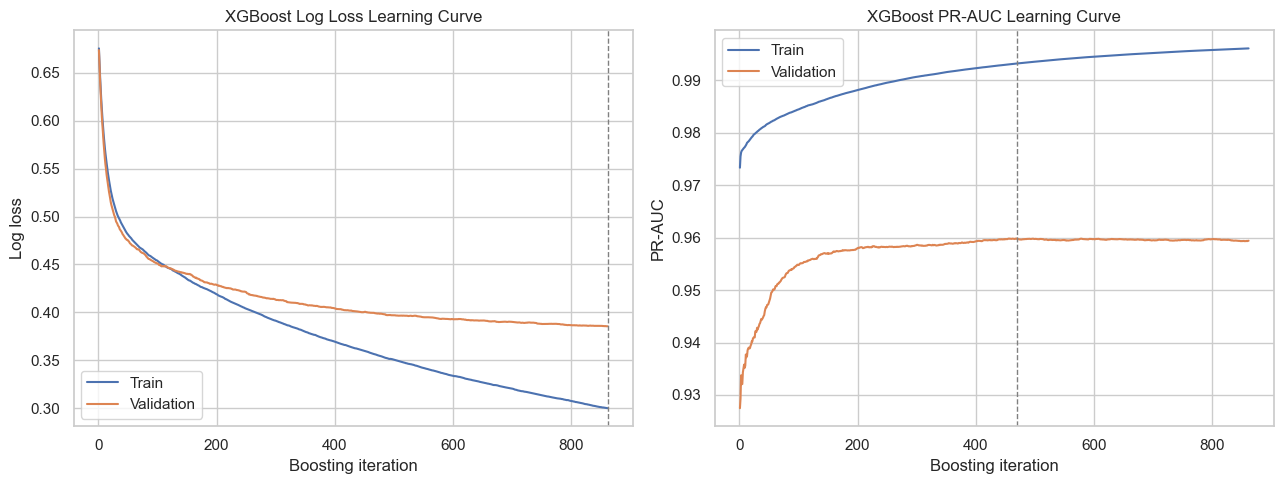

Using PR-AUC-pruned XGBoost for downstream evaluation.
Pruned n_estimators: 469


,iteration,train_logloss,valid_logloss,train_aucpr,valid_aucpr
856,857,0.300228,0.385598,0.996102,0.959358
857,858,0.300048,0.385487,0.996107,0.959394
858,859,0.299959,0.385498,0.996113,0.959351
859,860,0.299847,0.385400,0.996117,0.959401
860,861,0.299830,0.385373,0.996120,0.959425


In [6]:
# Refit the selected configuration with training + validation monitoring.
# This preserves the selected hyperparameters while making overfitting diagnostics explicit.
if best_trial is None:
    # Backward-compatible fallback if this cell is run with an older kernel state.
    best_trial = int(search_df.iloc[0]["trial"])

xgb_curve_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric=["logloss", "aucpr"],
    tree_method="hist",
    device=XGB_DEVICE,
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE + int(best_trial),
    n_jobs=-1,
    **best_params,
)

xgb_curve_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=False,
)

# Use the instrumented model downstream so all later metrics match the plotted learning curves.
best_model = xgb_curve_model
xgb_evals = xgb_curve_model.evals_result()
train_key, valid_key = list(xgb_evals.keys())[0], list(xgb_evals.keys())[1]

xgb_learning_curve_df = pd.DataFrame({
    "iteration": np.arange(1, len(xgb_evals[train_key]["logloss"]) + 1),
    "train_logloss": xgb_evals[train_key]["logloss"],
    "valid_logloss": xgb_evals[valid_key]["logloss"],
    "train_aucpr": xgb_evals[train_key]["aucpr"],
    "valid_aucpr": xgb_evals[valid_key]["aucpr"],
})
xgb_learning_curve_df.to_csv(TABLES_DIR / "xgboost_learning_curves.csv", index=False)

best_valid_aucpr_iter = int(xgb_learning_curve_df.loc[xgb_learning_curve_df["valid_aucpr"].idxmax(), "iteration"])
best_valid_logloss_iter = int(xgb_learning_curve_df.loc[xgb_learning_curve_df["valid_logloss"].idxmin(), "iteration"])
print("Best validation PR-AUC iteration:", best_valid_aucpr_iter)
print("Best validation logloss iteration:", best_valid_logloss_iter)
print("Final train-valid PR-AUC gap:", float(xgb_learning_curve_df.iloc[-1]["train_aucpr"] - xgb_learning_curve_df.iloc[-1]["valid_aucpr"]))
print("Final valid PR-AUC:", float(xgb_learning_curve_df.iloc[-1]["valid_aucpr"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["train_logloss"], label="Train")
axes[0].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["valid_logloss"], label="Validation")
axes[0].axvline(best_valid_logloss_iter, linestyle="--", color="gray", linewidth=1)
axes[0].set_title("XGBoost Log Loss Learning Curve")
axes[0].set_xlabel("Boosting iteration")
axes[0].set_ylabel("Log loss")
axes[0].legend()

axes[1].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["train_aucpr"], label="Train")
axes[1].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["valid_aucpr"], label="Validation")
axes[1].axvline(best_valid_aucpr_iter, linestyle="--", color="gray", linewidth=1)
axes[1].set_title("XGBoost PR-AUC Learning Curve")
axes[1].set_xlabel("Boosting iteration")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_learning_curves.png", dpi=180)
plt.show()


# Overfitting-control option: prune XGBoost to the boosting round with best validation PR-AUC.
# This usually reduces train-validation gap with little or no loss in temporal test ranking.
USE_PR_AUC_PRUNED_XGBOOST = True

if USE_PR_AUC_PRUNED_XGBOOST:
    pruned_params = dict(best_params)
    pruned_params["n_estimators"] = best_valid_aucpr_iter
    xgb_pruned_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        device=XGB_DEVICE,
        enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE + int(best_trial),
        n_jobs=-1,
        **pruned_params,
    )
    xgb_pruned_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    best_model = xgb_pruned_model
    best_params = pruned_params
    joblib.dump(best_model, MODELS_DIR / "sota_native_categorical_xgboost_pruned.joblib")
    print("Using PR-AUC-pruned XGBoost for downstream evaluation.")
    print("Pruned n_estimators:", best_valid_aucpr_iter)
else:
    joblib.dump(best_model, MODELS_DIR / "sota_native_categorical_xgboost_full.joblib")

xgb_learning_curve_df.tail()


## 7. Validation-Optimized Threshold

A 0.50 threshold is rarely optimal for imbalanced problems. We select the threshold on validation data, then apply it once to test data.


In [7]:
def metrics_at_threshold(y_true, proba, threshold):
    y_true = np.asarray(y_true)
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) else 0.0,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }

valid_proba = best_model.predict_proba(X_valid)[:, 1]
test_proba = best_model.predict_proba(X_test)[:, 1]

threshold_rows = []
for threshold in THRESHOLD_GRID:
    row = {"split": "validation"}
    row.update(metrics_at_threshold(y_valid, valid_proba, threshold))
    threshold_rows.append(row)
threshold_df = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_df.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]
BEST_THRESHOLD = float(best_threshold_row["threshold"])
print("Best validation threshold:", BEST_THRESHOLD)
best_threshold_row.to_frame().T


Best validation threshold: 0.66


,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
46,validation,0.66,0.770325,0.757065,0.930164,0.777868,0.847226,0.263738,0.222132,25826,1939,5413,7375


## 8. Final Test Evaluation


In [8]:
def summarize_model(split_name, y_true, proba, threshold):
    row = {
        "model": "native_categorical_xgboost_tuned",
        "split": split_name,
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision": average_precision_score(y_true, proba),
    }
    row.update(metrics_at_threshold(y_true, proba, threshold))
    return row

results_df = pd.DataFrame([
    summarize_model("validation", y_valid, valid_proba, BEST_THRESHOLD),
    summarize_model("test", y_test, test_proba, BEST_THRESHOLD),
    summarize_model("test_threshold_0_50", y_test, test_proba, 0.50),
])
results_df.to_csv(TABLES_DIR / "sota_xgboost_model_metrics.csv", index=False)
joblib.dump(best_model, MODELS_DIR / "sota_native_categorical_xgboost.joblib")
results_df


,model,split,roc_auc,average_precision,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,native_categorical_xgboost_tuned,validation,0.851276,0.959855,0.66,0.770325,0.757065,0.930164,0.777868,0.847226,0.263738,0.222132,25826,1939,5413,7375
1,native_categorical_xgboost_tuned,test,0.819247,0.959252,0.66,0.743174,0.725550,0.932641,0.750957,0.831996,0.299856,0.249043,20215,1460,3409,6704
2,native_categorical_xgboost_tuned,test_threshold_0_50,0.819247,0.959252,0.50,0.812948,0.708624,0.914896,0.859022,0.886079,0.441774,0.140978,23124,2151,2718,3795


## 9. Plots


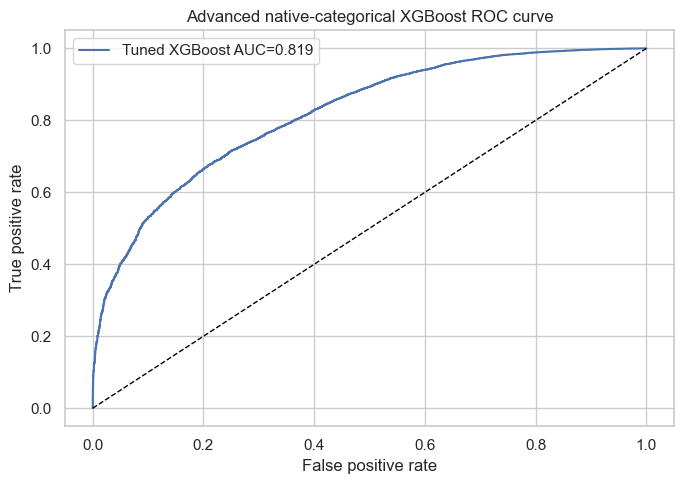

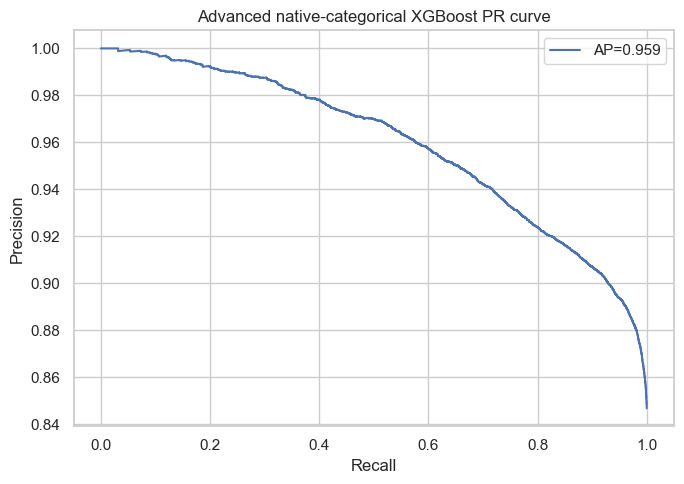

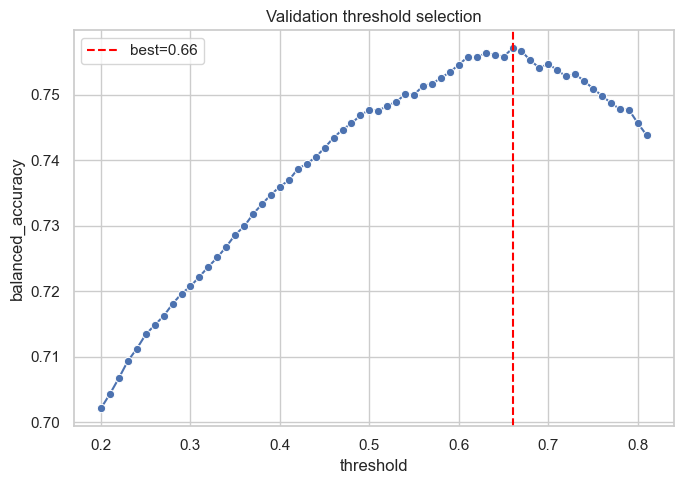

In [9]:
plt.figure(figsize=(7, 5))
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.plot(fpr, tpr, label=f"Tuned XGBoost AUC={roc_auc_score(y_test, test_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Advanced native-categorical XGBoost ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sota_xgboost_roc_curve.png", dpi=180)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP={average_precision_score(y_test, test_proba):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Advanced native-categorical XGBoost PR curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sota_xgboost_precision_recall_curve.png", dpi=180)
plt.show()

plt.figure(figsize=(7, 5))
sns.lineplot(data=threshold_df, x="threshold", y="balanced_accuracy", marker="o")
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"best={BEST_THRESHOLD:.2f}")
plt.title("Validation threshold selection")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sota_xgboost_threshold_selection.png", dpi=180)
plt.show()


## 10. Feature Importance / SHAP


c:\Users\Paulo Tumabing\.conda\envs\ml-course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP failed, using built-in importance instead: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 2.471588, while the model output was 4.399015. If this difference is acceptable you can set check_additivity=False to disable this check.


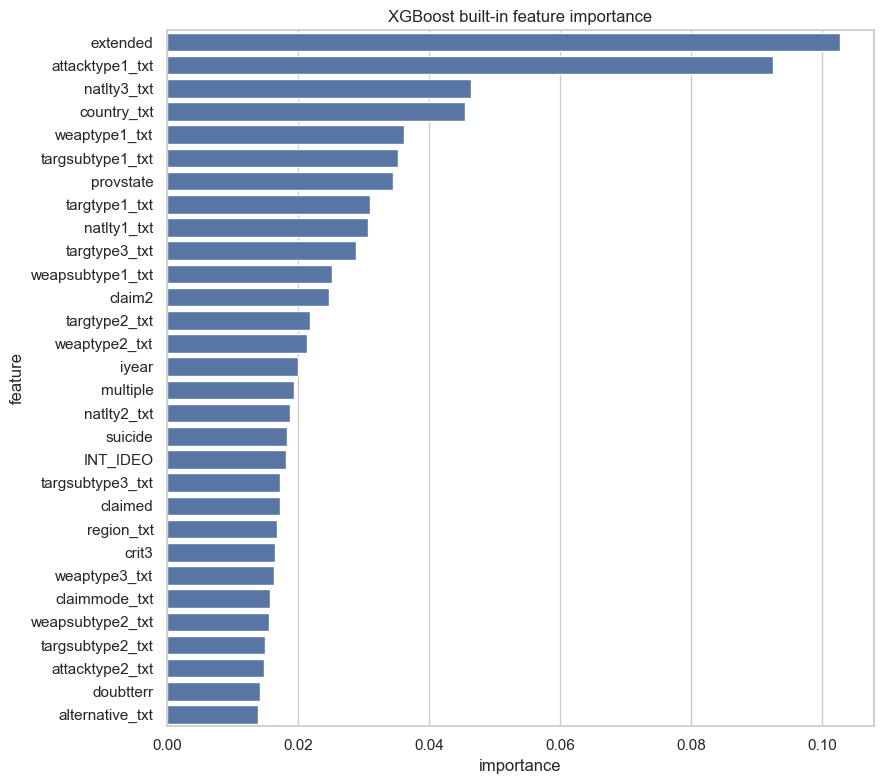

,feature,importance
3,extended,0.102772
31,attacktype1_txt,0.092537
42,natlty3_txt,0.046389
27,country_txt,0.045475
43,weaptype1_txt,0.036232
35,targsubtype1_txt,0.035230
28,provstate,0.034518
34,targtype1_txt,0.031002
36,natlty1_txt,0.030766
40,targtype3_txt,0.028902


In [10]:
if RUN_SHAP:
    try:
        import shap
        shap_sample = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(shap_sample)
        importance_df = pd.DataFrame({
            "feature": shap_sample.columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        }).sort_values("mean_abs_shap", ascending=False).head(30)
        x_axis = "mean_abs_shap"
        title = "Mean absolute SHAP value"
    except Exception as exc:
        print("SHAP failed, using built-in importance instead:", exc)
        importance_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": best_model.feature_importances_,
        }).sort_values("importance", ascending=False).head(30)
        x_axis = "importance"
        title = "XGBoost built-in feature importance"
else:
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(30)
    x_axis = "importance"
    title = "XGBoost built-in feature importance"

importance_df.to_csv(TABLES_DIR / "sota_xgboost_feature_importance.csv", index=False)
plt.figure(figsize=(9, 8))
sns.barplot(data=importance_df, x=x_axis, y="feature")
plt.title(title)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sota_xgboost_feature_importance.png", dpi=180)
plt.show()
importance_df


## 11. Subgroup Error Analysis


In [11]:
def subgroup_errors(X_frame, y_true, proba, subgroup_column, threshold, min_group_size=75):
    pred = (proba >= threshold).astype(int)
    frame = pd.DataFrame({
        "group": X_frame[subgroup_column].astype("string").fillna("Unknown").to_numpy(),
        "y": np.asarray(y_true),
        "pred": pred,
    })
    rows = []
    for group, g in frame.groupby("group", dropna=False):
        if len(g) < min_group_size:
            continue
        tn, fp, fn, tp = confusion_matrix(g.y, g.pred, labels=[0, 1]).ravel()
        rows.append({
            "subgroup_column": subgroup_column,
            "group": group,
            "n": len(g),
            "base_success_rate": float(g.y.mean()),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) else 0.0,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        })
    return pd.DataFrame(rows)

subgroup_columns = [c for c in ["region_txt", "country_txt", "attacktype1_txt", "targtype1_txt", "weaptype1_txt"] if c in X_test.columns]
subgroup_df = pd.concat([
    subgroup_errors(X_test, y_test, test_proba, col, BEST_THRESHOLD) for col in subgroup_columns
], ignore_index=True)
subgroup_df.to_csv(TABLES_DIR / "sota_xgboost_subgroup_error_analysis.csv", index=False)
subgroup_df.sort_values(["false_negative_rate", "n"], ascending=[False, False]).head(20)


,subgroup_column,group,n,base_success_rate,false_positive_rate,false_negative_rate,tp,fp,tn,fn
72,targtype1_txt,Unknown,1438,0.321280,0.002049,0.997835,1,2,974,461
50,attacktype1_txt,Assassination,2615,0.635564,0.012592,0.924188,126,12,941,1536
28,country_txt,Mexico,92,0.902174,0.111111,0.710843,24,1,8,59
45,country_txt,United Kingdom,316,0.731013,0.023529,0.610390,90,2,83,141
24,country_txt,Israel,296,0.706081,0.149425,0.607656,82,13,74,127
47,country_txt,West Bank and Gaza Strip,318,0.606918,0.048000,0.601036,77,6,119,116
74,targtype1_txt,Violent Political Party,211,0.753555,0.134615,0.591195,65,7,45,94
2,region_txt,North America,407,0.842752,0.109375,0.545190,156,7,57,187
35,country_txt,Philippines,1466,0.781037,0.183801,0.531004,537,59,262,608
46,country_txt,United States,277,0.815884,0.117647,0.517699,109,6,45,117



## 12. Manuscript-Grade Robustness Additions

The tuned native-categorical XGBoost model is the strongest model in this notebook, but a conference-style manuscript should not report it in isolation. The following additions strengthen the experimental design by adding:

1. **Naive and empirical baselines** so the model is compared against simple decision rules.
2. **Failure-class PR-AUC** because `success=1` is the majority class and ordinary average precision can look high even for weak models.
3. **Matthews correlation coefficient and Brier score** to better evaluate imbalanced classification and probability quality.
4. **Calibration diagnostics** because threshold simulations assume that predicted probabilities are meaningful.
5. **Strict-feature leakage sensitivity analysis** to test how much performance depends on features that may only be known during event coding rather than before an attack outcome is fully known.


In [12]:

from sklearn.metrics import brier_score_loss, matthews_corrcoef
from sklearn.calibration import calibration_curve


def safe_roc_auc(y_true, proba):
    try:
        return roc_auc_score(y_true, proba)
    except ValueError:
        return np.nan


def robust_binary_metrics(model_name, split_name, y_true, proba, threshold=0.50):
    """Metrics emphasizing imbalance, failure-class detection, and probability quality."""
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "split": split_name,
        "threshold": float(threshold),
        "roc_auc": safe_roc_auc(y_true, proba),
        "average_precision_success": average_precision_score(y_true, proba),
        "average_precision_failure": average_precision_score(1 - y_true, 1 - proba),
        "brier_score": brier_score_loss(y_true, proba),
        "mcc": matthews_corrcoef(y_true, pred),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_success": precision_score(y_true, pred, zero_division=0),
        "recall_success": recall_score(y_true, pred, zero_division=0),
        "f1_success": f1_score(y_true, pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) else 0.0,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }


def empirical_group_rate_proba(X_reference, y_reference, X_eval, keys, smoothing=50.0):
    """Smoothed historical success-rate baseline using grouped training frequencies."""
    available_keys = [k for k in keys if k in X_reference.columns and k in X_eval.columns]
    global_rate = float(np.mean(y_reference))
    if not available_keys:
        return np.full(len(X_eval), global_rate)

    ref = X_reference[available_keys].astype("string").fillna("Unknown").copy()
    ref["__y__"] = np.asarray(y_reference).astype(float)
    ref["__key__"] = ref[available_keys].agg("||".join, axis=1)
    grouped = ref.groupby("__key__")["__y__"].agg(["sum", "count"])
    grouped["rate"] = (grouped["sum"] + smoothing * global_rate) / (grouped["count"] + smoothing)

    eval_keys = X_eval[available_keys].astype("string").fillna("Unknown").agg("||".join, axis=1)
    return eval_keys.map(grouped["rate"]).fillna(global_rate).to_numpy(dtype=float)


baseline_rows = []
train_prevalence = float(np.mean(y_train))

for split_name, X_split, y_split, tuned_proba in [
    ("validation", X_valid, y_valid, valid_proba),
    ("test", X_test, y_test, test_proba),
]:
    n = len(y_split)
    baseline_rows.append(robust_binary_metrics(
        "always_success_baseline", split_name, y_split, np.ones(n), threshold=0.50
    ))
    baseline_rows.append(robust_binary_metrics(
        "train_prevalence_constant_baseline", split_name, y_split, np.full(n, train_prevalence), threshold=0.50
    ))
    empirical_proba = empirical_group_rate_proba(
        X_train, y_train, X_split, keys=["country_txt", "attacktype1_txt", "targtype1_txt"], smoothing=50.0
    )
    baseline_rows.append(robust_binary_metrics(
        "smoothed_country_attack_target_rate_baseline", split_name, y_split, empirical_proba, threshold=0.50
    ))
    baseline_rows.append(robust_binary_metrics(
        "native_categorical_xgboost_tuned", split_name, y_split, tuned_proba,
        threshold=BEST_THRESHOLD,
    ))

robust_comparison_df = pd.DataFrame(baseline_rows)
robust_comparison_df.to_csv(TABLES_DIR / "sota_robust_model_comparison.csv", index=False)
robust_comparison_df.sort_values(["split", "average_precision_failure", "balanced_accuracy"], ascending=[True, False, False])


,model,split,threshold,roc_auc,average_precision_success,average_precision_failure,brier_score,mcc,accuracy,balanced_accuracy,precision_success,recall_success,f1_success,false_positive_rate,false_negative_rate,tp,fp,tn,fn
7,native_categorical_xgboost_tuned,test,0.66,0.819247,0.959252,0.512137,0.134916,0.348821,0.743174,0.725550,0.932641,0.750957,0.831996,0.299856,0.249043,20215,1460,3409,6704
6,smoothed_country_attack_target_rate_baseline,test,0.50,0.724595,0.924028,0.394423,0.116827,0.204047,0.854096,0.536171,0.856371,0.994502,0.920282,0.922161,0.005498,26771,4490,379,148
4,always_success_baseline,test,0.50,0.500000,0.846829,0.153171,0.153171,0.000000,0.846829,0.500000,0.846829,1.000000,0.917063,1.000000,0.000000,26919,4869,0,0
5,train_prevalence_constant_baseline,test,0.50,0.500000,0.846829,0.153171,0.133603,0.000000,0.846829,0.500000,0.846829,1.000000,0.917063,1.000000,0.000000,26919,4869,0,0
3,native_categorical_xgboost_tuned,validation,0.66,0.851276,0.959855,0.625182,0.127320,0.426286,0.770325,0.757065,0.930164,0.777868,0.847226,0.263738,0.222132,25826,1939,5413,7375
2,smoothed_country_attack_target_rate_baseline,validation,0.50,0.755617,0.913102,0.532367,0.124446,0.365804,0.848445,0.593138,0.847509,0.993675,0.914790,0.807399,0.006325,32991,5936,1416,210
0,always_success_baseline,validation,0.50,0.500000,0.818706,0.181294,0.181294,0.000000,0.818706,0.500000,0.818706,1.000000,0.900317,1.000000,0.000000,33201,7352,0,0
1,train_prevalence_constant_baseline,validation,0.50,0.500000,0.818706,0.181294,0.156621,0.000000,0.818706,0.500000,0.818706,1.000000,0.900317,1.000000,0.000000,33201,7352,0,0



## 13. Probability Calibration Analysis

Threshold simulations are more defensible when model scores are reasonably calibrated. The Brier score above summarizes calibration and sharpness; the reliability curve below visualizes whether predicted probabilities correspond to observed success frequencies.


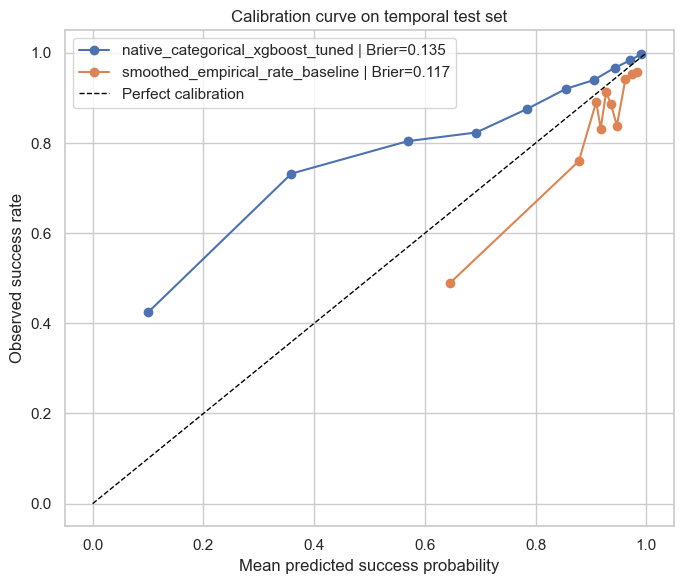

,model,bin,mean_predicted_probability,observed_success_rate,brier_score
0,native_categorical_xgboost_tuned,1,0.099951,0.424347,0.134916
1,native_categorical_xgboost_tuned,2,0.359075,0.732306,0.134916
2,native_categorical_xgboost_tuned,3,0.569201,0.804341,0.134916
3,native_categorical_xgboost_tuned,4,0.692717,0.823474,0.134916
4,native_categorical_xgboost_tuned,5,0.785147,0.876062,0.134916
5,native_categorical_xgboost_tuned,6,0.855543,0.920730,0.134916
6,native_categorical_xgboost_tuned,7,0.905303,0.939899,0.134916
7,native_categorical_xgboost_tuned,8,0.942702,0.966971,0.134916
8,native_categorical_xgboost_tuned,9,0.970494,0.983328,0.134916
9,native_categorical_xgboost_tuned,10,0.989877,0.996854,0.134916


In [13]:

calibration_rows = []
plt.figure(figsize=(7, 6))

for model_name, proba in [
    ("native_categorical_xgboost_tuned", test_proba),
    ("smoothed_empirical_rate_baseline", empirical_group_rate_proba(
        X_train, y_train, X_test, keys=["country_txt", "attacktype1_txt", "targtype1_txt"], smoothing=50.0
    )),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    for bin_id, (mp, fp_rate) in enumerate(zip(mean_pred, frac_pos), start=1):
        calibration_rows.append({
            "model": model_name,
            "bin": bin_id,
            "mean_predicted_probability": mp,
            "observed_success_rate": fp_rate,
            "brier_score": brier_score_loss(y_test, proba),
        })
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} | Brier={brier_score_loss(y_test, proba):.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Perfect calibration")
plt.xlabel("Mean predicted success probability")
plt.ylabel("Observed success rate")
plt.title("Calibration curve on temporal test set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sota_xgboost_calibration_curve.png", dpi=180)
plt.show()

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(TABLES_DIR / "sota_xgboost_calibration_curve.csv", index=False)
calibration_df



## 14. Strict-Feature Leakage Sensitivity Audit

The expanded SOTA feature set is useful for a high-performing event-record classifier. However, some variables may be known only during incident coding or after the outcome is clearer. This audit trains the same XGBoost configuration after removing potentially coding-time/post-outcome-sensitive variables.

This is not claiming that all listed variables are invalid. Instead, it tests whether the reported performance is robust to a stricter causal/predictive assumption.


In [14]:

RUN_STRICT_FEATURE_AUDIT = True

POTENTIAL_CODING_TIME_OR_LEAKAGE_COLUMNS = [
    "extended",        # may require knowing event duration
    "claimed", "claim2", "claim3", "compclaim",
    "claimmode_txt", "claimmode2_txt", "claimmode3_txt",
    "alternative_txt",
    "crit1", "crit2", "crit3",
    "doubtterr",
]

strict_audit_df = pd.DataFrame()

if RUN_STRICT_FEATURE_AUDIT:
    strict_drop = [c for c in POTENTIAL_CODING_TIME_OR_LEAKAGE_COLUMNS if c in X_train.columns]
    strict_columns = [c for c in X_train.columns if c not in strict_drop]
    print("Strict audit dropping columns:", strict_drop)
    print("Strict feature count:", len(strict_columns), "of", X_train.shape[1])

    strict_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        device=XGB_DEVICE,
        enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE + 10000,
        n_jobs=-1,
        **best_params,
    )
    strict_model.fit(
        X_train[strict_columns], y_train,
        eval_set=[(X_valid[strict_columns], y_valid)],
        verbose=False,
    )

    strict_valid_proba = strict_model.predict_proba(X_valid[strict_columns])[:, 1]
    strict_test_proba = strict_model.predict_proba(X_test[strict_columns])[:, 1]

    strict_threshold_rows = []
    for threshold in THRESHOLD_GRID:
        row = {"threshold": threshold}
        row.update(metrics_at_threshold(y_valid, strict_valid_proba, threshold))
        strict_threshold_rows.append(row)
    strict_threshold_df = pd.DataFrame(strict_threshold_rows)
    strict_best_threshold = float(
        strict_threshold_df.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]["threshold"]
    )
    print("Strict-feature best validation threshold:", strict_best_threshold)

    strict_audit_df = pd.DataFrame([
        robust_binary_metrics("expanded_native_categorical_xgboost", "validation", y_valid, valid_proba, BEST_THRESHOLD),
        robust_binary_metrics("expanded_native_categorical_xgboost", "test", y_test, test_proba, BEST_THRESHOLD),
        robust_binary_metrics("strict_feature_xgboost_same_search_space", "validation", y_valid, strict_valid_proba, strict_best_threshold),
        robust_binary_metrics("strict_feature_xgboost_same_search_space", "test", y_test, strict_test_proba, strict_best_threshold),
    ])
    strict_audit_df["dropped_columns"] = ", ".join(strict_drop)
    strict_audit_df.to_csv(TABLES_DIR / "sota_strict_feature_leakage_audit.csv", index=False)
    joblib.dump(strict_model, MODELS_DIR / "sota_strict_feature_xgboost.joblib")
else:
    print("Strict feature audit skipped. Set RUN_STRICT_FEATURE_AUDIT=True for final manuscript runs.")

strict_audit_df


Strict audit dropping columns: ['extended', 'claimed', 'claim2', 'claim3', 'compclaim', 'claimmode_txt', 'claimmode2_txt', 'claimmode3_txt', 'alternative_txt', 'crit1', 'crit2', 'crit3', 'doubtterr']
Strict feature count: 39 of 52
Strict-feature best validation threshold: 0.68


,model,split,threshold,roc_auc,average_precision_success,average_precision_failure,brier_score,mcc,accuracy,balanced_accuracy,precision_success,recall_success,f1_success,false_positive_rate,false_negative_rate,tp,fp,tn,fn,dropped_columns
0,expanded_native_categorical_xgboost,validation,0.66,0.851276,0.959855,0.625182,0.127320,0.426286,0.770325,0.757065,0.930164,0.777868,0.847226,0.263738,0.222132,25826,1939,5413,7375,"extended, claimed, claim2, claim3, compclaim, ..."
1,expanded_native_categorical_xgboost,test,0.66,0.819247,0.959252,0.512137,0.134916,0.348821,0.743174,0.725550,0.932641,0.750957,0.831996,0.299856,0.249043,20215,1460,3409,6704,"extended, claimed, claim2, claim3, compclaim, ..."
2,strict_feature_xgboost_same_search_space,validation,0.68,0.840141,0.955802,0.615873,0.131523,0.395611,0.748502,0.742519,0.927134,0.751905,0.830376,0.266866,0.248095,24964,1962,5390,8237,"extended, claimed, claim2, claim3, compclaim, ..."
3,strict_feature_xgboost_same_search_space,test,0.68,0.810773,0.955772,0.501903,0.134628,0.338501,0.738392,0.719278,0.930525,0.746833,0.828621,0.308277,0.253167,20104,1501,3368,6815,"extended, claimed, claim2, claim3, compclaim, ..."


## 15. Overfitting-Controlled CatBoost Challenger

CatBoost is retained as a categorical SOTA challenger, but this version uses stronger regularization and early stopping to reduce the larger train-validation gap observed in the first run. The model uses shallower trees, stronger L2 regularization, Bayesian bagging, gentler square-root class weighting, randomized split scoring, and overfitting detection.


In [15]:

RUN_CATBOOST_CHALLENGER = True  # Set True if catboost is installed and runtime is acceptable.
catboost_results_df = pd.DataFrame()

if RUN_CATBOOST_CHALLENGER:
    try:
        from catboost import CatBoostClassifier

        cat_features = [i for i, c in enumerate(X_train.columns) if str(X_train[c].dtype) == "category"]
        # Regularized CatBoost configuration to reduce overfitting.
        # Changes vs the earlier challenger: shallower trees, stronger L2,
        # randomized splits, Bayesian bagging, gentler class weighting, and early stopping.
        cat_model = CatBoostClassifier(
            iterations=2500,
            learning_rate=0.025,
            depth=5,
            l2_leaf_reg=12.0,
            random_strength=2.0,
            bootstrap_type="Bayesian",
            bagging_temperature=1.0,
            loss_function="Logloss",
            eval_metric="PRAUC",
            custom_metric=["Logloss", "PRAUC"],
            od_type="Iter",
            od_wait=120,
            random_seed=RANDOM_STATE,
            auto_class_weights="SqrtBalanced",
            verbose=100,
            allow_writing_files=False,
            task_type="GPU" if XGB_DEVICE == "cuda" else "CPU",
        )
        cat_model.fit(
            X_train, y_train,
            cat_features=cat_features,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
        )

        # CatBoost training/validation curves for overfitting diagnostics.
        cat_evals = cat_model.get_evals_result()
        learn_metrics = cat_evals.get("learn", {})
        valid_name = [k for k in cat_evals.keys() if k != "learn"][0]
        valid_metrics = cat_evals.get(valid_name, {})

        if learn_metrics and valid_metrics:
            cat_curve_data = {"iteration": np.arange(1, len(next(iter(learn_metrics.values()))) + 1)}
            for metric_name, values in learn_metrics.items():
                cat_curve_data[f"train_{metric_name.lower()}"] = values
            for metric_name, values in valid_metrics.items():
                cat_curve_data[f"valid_{metric_name.lower()}"] = values
            catboost_learning_curve_df = pd.DataFrame(cat_curve_data)
            catboost_learning_curve_df.to_csv(TABLES_DIR / "catboost_learning_curves.csv", index=False)

            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            metric_columns = catboost_learning_curve_df.columns.tolist()
            train_loss_col = next((col for col in metric_columns if col.startswith("train_logloss")), None)
            valid_loss_col = next((col for col in metric_columns if col.startswith("valid_logloss")), None)
            train_auc_col = next((col for col in metric_columns if col.startswith("train_prauc") or col.startswith("train_auc")), None)
            valid_auc_col = next((col for col in metric_columns if col.startswith("valid_prauc") or col.startswith("valid_auc")), None)

            if train_loss_col and valid_loss_col:
                axes[0].plot(catboost_learning_curve_df["iteration"], catboost_learning_curve_df[train_loss_col], label="Train")
                axes[0].plot(catboost_learning_curve_df["iteration"], catboost_learning_curve_df[valid_loss_col], label="Validation")
                axes[0].set_title("CatBoost Log Loss Learning Curve")
                axes[0].set_xlabel("Boosting iteration")
                axes[0].set_ylabel("Log loss")
                axes[0].legend()
            else:
                axes[0].axis("off")
                axes[0].set_title("CatBoost log loss not available")

            if train_auc_col and valid_auc_col:
                best_cat_iter = int(catboost_learning_curve_df.loc[catboost_learning_curve_df[valid_auc_col].idxmax(), "iteration"])
                axes[1].plot(catboost_learning_curve_df["iteration"], catboost_learning_curve_df[train_auc_col], label="Train")
                axes[1].plot(catboost_learning_curve_df["iteration"], catboost_learning_curve_df[valid_auc_col], label="Validation")
                axes[1].axvline(best_cat_iter, linestyle="--", color="gray", linewidth=1)
                axes[1].set_title("CatBoost PR-AUC Learning Curve")
                axes[1].set_xlabel("Boosting iteration")
                axes[1].set_ylabel("PR-AUC")
                axes[1].legend()
                print("Best CatBoost validation PR-AUC iteration:", best_cat_iter)
                print("Final CatBoost train-valid PR-AUC gap:", float(catboost_learning_curve_df.iloc[-1][train_auc_col] - catboost_learning_curve_df.iloc[-1][valid_auc_col]))
            else:
                axes[1].axis("off")
                axes[1].set_title("CatBoost PR-AUC not available")

            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "catboost_learning_curves.png", dpi=180)
            plt.show()
        else:
            print("CatBoost eval history was unavailable; learning curves were not saved.")

        cat_valid_proba = cat_model.predict_proba(X_valid)[:, 1]
        cat_test_proba = cat_model.predict_proba(X_test)[:, 1]

        cat_threshold_df = pd.DataFrame([
            {"threshold": t, **metrics_at_threshold(y_valid, cat_valid_proba, t)} for t in THRESHOLD_GRID
        ])
        cat_best_threshold = float(cat_threshold_df.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]["threshold"])
        catboost_results_df = pd.DataFrame([
            robust_binary_metrics("regularized_catboost_challenger", "validation", y_valid, cat_valid_proba, cat_best_threshold),
            robust_binary_metrics("regularized_catboost_challenger", "test", y_test, cat_test_proba, cat_best_threshold),
        ])
        catboost_results_df.to_csv(TABLES_DIR / "regularized_catboost_challenger_metrics.csv", index=False)
        joblib.dump(cat_model, MODELS_DIR / "regularized_catboost_challenger.joblib")
    except ImportError:
        print("CatBoost is not installed. Optional challenger skipped.")
    except Exception as exc:
        print("CatBoost challenger failed and was skipped:", exc)
else:
    print("CatBoost challenger skipped. Set RUN_CATBOOST_CHALLENGER=True after installing catboost.")

catboost_results_df


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.8970591	test: 0.7371105	best: 0.7371105 (0)	total: 68.2ms	remaining: 2m 50s
100:	learn: 0.9271706	test: 0.7923208	best: 0.7923208 (100)	total: 5.67s	remaining: 2m 14s
200:	learn: 0.9338494	test: 0.8216958	best: 0.8216958 (200)	total: 11.5s	remaining: 2m 11s
300:	learn: 0.9373350	test: 0.8371611	best: 0.8372141 (299)	total: 17.4s	remaining: 2m 6s
400:	learn: 0.9397306	test: 0.8474463	best: 0.8474463 (400)	total: 23s	remaining: 2m
500:	learn: 0.9415012	test: 0.8546763	best: 0.8546763 (500)	total: 28.6s	remaining: 1m 54s
600:	learn: 0.9430292	test: 0.8587684	best: 0.8589078 (597)	total: 34.5s	remaining: 1m 49s
700:	learn: 0.9442541	test: 0.8624705	best: 0.8624793 (699)	total: 40.2s	remaining: 1m 43s
800:	learn: 0.9452330	test: 0.8650347	best: 0.8650347 (800)	total: 45.8s	remaining: 1m 37s
900:	learn: 0.9460816	test: 0.8678521	best: 0.8678521 (900)	total: 51.5s	remaining: 1m 31s
1000:	learn: 0.9468353	test: 0.8688007	best: 0.8688224 (999)	total: 57.3s	remaining: 1m 25s
1100:	le

""


## 16. Validation-Tuned XGBoost + CatBoost Ensemble

Because XGBoost and CatBoost use different categorical-splitting strategies, their probability rankings may contain complementary information. This section tunes a simple weighted probability average on the validation set, then evaluates the selected ensemble once on the temporal test set.


In [16]:

ensemble_results_df = pd.DataFrame()

if "cat_valid_proba" in globals() and "cat_test_proba" in globals() and len(catboost_results_df) > 0:
    ensemble_rows = []
    for weight_xgb in np.round(np.arange(0.0, 1.01, 0.05), 2):
        weight_cat = 1.0 - weight_xgb
        ens_valid_proba = weight_xgb * valid_proba + weight_cat * cat_valid_proba
        valid_ap = average_precision_score(y_valid, ens_valid_proba)
        valid_auc = roc_auc_score(y_valid, ens_valid_proba)
        # Choose each ensemble threshold using validation balanced accuracy.
        threshold_candidates = []
        for threshold in THRESHOLD_GRID:
            row = {"threshold": threshold}
            row.update(metrics_at_threshold(y_valid, ens_valid_proba, threshold))
            threshold_candidates.append(row)
        threshold_frame = pd.DataFrame(threshold_candidates)
        best_threshold_row = threshold_frame.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]
        ensemble_rows.append({
            "weight_xgboost": float(weight_xgb),
            "weight_catboost": float(weight_cat),
            "valid_average_precision_success": valid_ap,
            "valid_roc_auc": valid_auc,
            "valid_best_threshold": float(best_threshold_row["threshold"]),
            "valid_balanced_accuracy_at_threshold": float(best_threshold_row["balanced_accuracy"]),
        })

    ensemble_search_df = pd.DataFrame(ensemble_rows).sort_values(
        ["valid_average_precision_success", "valid_roc_auc"], ascending=False
    )
    ensemble_search_df.to_csv(TABLES_DIR / "pruned_xgboost_regularized_catboost_ensemble_weight_search.csv", index=False)

    best_ensemble = ensemble_search_df.iloc[0]
    BEST_ENSEMBLE_WEIGHT_XGB = float(best_ensemble["weight_xgboost"])
    BEST_ENSEMBLE_WEIGHT_CAT = float(best_ensemble["weight_catboost"])
    BEST_ENSEMBLE_THRESHOLD = float(best_ensemble["valid_best_threshold"])

    ensemble_valid_proba = BEST_ENSEMBLE_WEIGHT_XGB * valid_proba + BEST_ENSEMBLE_WEIGHT_CAT * cat_valid_proba
    ensemble_test_proba = BEST_ENSEMBLE_WEIGHT_XGB * test_proba + BEST_ENSEMBLE_WEIGHT_CAT * cat_test_proba

    ensemble_results_df = pd.DataFrame([
        robust_binary_metrics("pruned_xgboost_regularized_catboost_ensemble", "validation", y_valid, ensemble_valid_proba, BEST_ENSEMBLE_THRESHOLD),
        robust_binary_metrics("pruned_xgboost_regularized_catboost_ensemble", "test", y_test, ensemble_test_proba, BEST_ENSEMBLE_THRESHOLD),
    ])
    ensemble_results_df["weight_xgboost"] = BEST_ENSEMBLE_WEIGHT_XGB
    ensemble_results_df["weight_catboost"] = BEST_ENSEMBLE_WEIGHT_CAT
    ensemble_results_df.to_csv(TABLES_DIR / "pruned_xgboost_regularized_catboost_ensemble_metrics.csv", index=False)

    final_champion_df = pd.concat([
        robust_comparison_df[robust_comparison_df["model"].eq("native_categorical_xgboost_tuned")],
        catboost_results_df,
        ensemble_results_df,
    ], ignore_index=True, sort=False)
    final_champion_df.to_csv(TABLES_DIR / "final_overfit_controlled_sota_comparison.csv", index=False)

    print("Best ensemble weights:", {"xgboost": BEST_ENSEMBLE_WEIGHT_XGB, "catboost": BEST_ENSEMBLE_WEIGHT_CAT})
    print("Best ensemble validation threshold:", BEST_ENSEMBLE_THRESHOLD)
    display(ensemble_search_df.head(10))
    display(final_champion_df.sort_values(["split", "average_precision_success", "balanced_accuracy"], ascending=[True, False, False]))
else:
    print("Ensemble skipped because CatBoost probabilities are unavailable. Run the CatBoost challenger with RUN_CATBOOST_CHALLENGER=True.")

ensemble_results_df


Ensemble skipped because CatBoost probabilities are unavailable. Run the CatBoost challenger with RUN_CATBOOST_CHALLENGER=True.


""


## 17. Overfitting Diagnostics Summary

This table summarizes train-validation gaps after applying overfitting controls. Smaller PR-AUC gaps and validation-loss curves that do not deteriorate strongly indicate better generalization.


In [17]:
overfit_rows = []

if "xgb_learning_curve_df" in globals():
    full_final = xgb_learning_curve_df.iloc[-1]
    pruned_row = xgb_learning_curve_df[xgb_learning_curve_df["iteration"].eq(best_valid_aucpr_iter)].iloc[0]
    overfit_rows.extend([
        {
            "model": "xgboost_full_curve_endpoint",
            "iteration": int(full_final["iteration"]),
            "train_metric": float(full_final["train_aucpr"]),
            "valid_metric": float(full_final["valid_aucpr"]),
            "train_valid_gap": float(full_final["train_aucpr"] - full_final["valid_aucpr"]),
            "valid_logloss": float(full_final["valid_logloss"]),
            "note": "Original selected n_estimators endpoint",
        },
        {
            "model": "xgboost_pruned_best_valid_prauc",
            "iteration": int(pruned_row["iteration"]),
            "train_metric": float(pruned_row["train_aucpr"]),
            "valid_metric": float(pruned_row["valid_aucpr"]),
            "train_valid_gap": float(pruned_row["train_aucpr"] - pruned_row["valid_aucpr"]),
            "valid_logloss": float(pruned_row["valid_logloss"]),
            "note": "Downstream XGBoost model after PR-AUC pruning",
        },
    ])

if "catboost_learning_curve_df" in globals():
    metric_columns = catboost_learning_curve_df.columns.tolist()
    train_auc_col = next((col for col in metric_columns if col.startswith("train_prauc") or col.startswith("train_auc")), None)
    valid_auc_col = next((col for col in metric_columns if col.startswith("valid_prauc") or col.startswith("valid_auc")), None)
    valid_loss_col = next((col for col in metric_columns if col.startswith("valid_logloss")), None)
    if train_auc_col and valid_auc_col:
        best_cat_idx = catboost_learning_curve_df[valid_auc_col].idxmax()
        best_cat = catboost_learning_curve_df.loc[best_cat_idx]
        overfit_rows.append({
            "model": "regularized_catboost_best_valid_prauc",
            "iteration": int(best_cat["iteration"]),
            "train_metric": float(best_cat[train_auc_col]),
            "valid_metric": float(best_cat[valid_auc_col]),
            "train_valid_gap": float(best_cat[train_auc_col] - best_cat[valid_auc_col]),
            "valid_logloss": float(best_cat[valid_loss_col]) if valid_loss_col else np.nan,
            "note": "Regularized CatBoost selected by validation PR-AUC/early stopping",
        })

overfitting_diagnostics_df = pd.DataFrame(overfit_rows)
overfitting_diagnostics_df.to_csv(TABLES_DIR / "overfitting_diagnostics_summary.csv", index=False)
overfitting_diagnostics_df


,model,iteration,train_metric,valid_metric,train_valid_gap,valid_logloss,note
0,xgboost_full_curve_endpoint,861,0.996120,0.959425,0.036695,0.385373,Original selected n_estimators endpoint
1,xgboost_pruned_best_valid_prauc,469,0.993236,0.959854,0.033383,0.398917,Downstream XGBoost model after PR-AUC pruning



## 18. Revised Manuscript Interpretation Notes

For the final paper, interpret the results in this order:

1. **Baseline comparison:** show that tuned XGBoost improves over naive and empirical baselines, not only over Logistic Regression.
2. **Class imbalance:** report failure-class AP and balanced accuracy because ordinary accuracy and success-class AP are inflated by the high success prevalence.
3. **Threshold sensitivity:** use the validation-selected threshold, but explain the policy tradeoff between false positives and false negatives.
4. **Calibration:** discuss whether predicted probabilities are reliable enough for threshold-based decision analysis.
5. **Leakage sensitivity:** compare expanded-feature and strict-feature XGBoost. If performance drops, frame the drop as evidence that modeling assumptions strongly affect conclusions.
6. **Subgroup disparities:** report FPR/FNR differences by region, country, attack type, target type, and weapon type as model-behavior disparities, not causal claims about those groups.

Recommended final claim: the project is not merely predicting attack success; it is studying how tabular ML models encode geopolitical, tactical, and dataset-coding structure under temporal shift and class imbalance.


## 19. Final Artifact Summary


In [18]:
print("Advanced SOTA-oriented notebook complete.")
print("Core XGBoost metrics:", TABLES_DIR / "sota_xgboost_model_metrics.csv")
print("CatBoost metrics:", TABLES_DIR / "regularized_catboost_challenger_metrics.csv")
print("Overfit-controlled ensemble metrics:", TABLES_DIR / "pruned_xgboost_regularized_catboost_ensemble_metrics.csv")
print("Final overfit-controlled comparison:", TABLES_DIR / "final_overfit_controlled_sota_comparison.csv")
print("Hyperparameter search:", TABLES_DIR / "sota_xgboost_hyperparameter_search.csv")
print("XGBoost learning curves:", TABLES_DIR / "xgboost_learning_curves.csv")
print("CatBoost learning curves:", TABLES_DIR / "catboost_learning_curves.csv")
print("Robust comparison:", TABLES_DIR / "sota_robust_model_comparison.csv")
print("Calibration table:", TABLES_DIR / "sota_xgboost_calibration_curve.csv")
print("Strict-feature audit:", TABLES_DIR / "sota_strict_feature_leakage_audit.csv")
print("Subgroup analysis:", TABLES_DIR / "sota_xgboost_subgroup_error_analysis.csv")
print("Pruned XGBoost model:", MODELS_DIR / "sota_native_categorical_xgboost_pruned.joblib")
print("CatBoost model:", MODELS_DIR / "regularized_catboost_challenger.joblib")
print("Strict-feature XGBoost model:", MODELS_DIR / "sota_strict_feature_xgboost.joblib")
print("Best XGBoost params:", best_params)
print("XGBoost validation-selected threshold:", BEST_THRESHOLD)
if "BEST_ENSEMBLE_WEIGHT_XGB" in globals():
    print("Best ensemble weights:", {"xgboost": BEST_ENSEMBLE_WEIGHT_XGB, "catboost": BEST_ENSEMBLE_WEIGHT_CAT})
    print("Best ensemble threshold:", BEST_ENSEMBLE_THRESHOLD)


Advanced SOTA-oriented notebook complete.
Core XGBoost metrics: c:\Documents\Compsci\CSELEC2C\Project\results\tables\sota_xgboost_model_metrics.csv
CatBoost metrics: c:\Documents\Compsci\CSELEC2C\Project\results\tables\regularized_catboost_challenger_metrics.csv
Overfit-controlled ensemble metrics: c:\Documents\Compsci\CSELEC2C\Project\results\tables\pruned_xgboost_regularized_catboost_ensemble_metrics.csv
Final overfit-controlled comparison: c:\Documents\Compsci\CSELEC2C\Project\results\tables\final_overfit_controlled_sota_comparison.csv
Hyperparameter search: c:\Documents\Compsci\CSELEC2C\Project\results\tables\sota_xgboost_hyperparameter_search.csv
XGBoost learning curves: c:\Documents\Compsci\CSELEC2C\Project\results\tables\xgboost_learning_curves.csv
CatBoost learning curves: c:\Documents\Compsci\CSELEC2C\Project\results\tables\catboost_learning_curves.csv
Robust comparison: c:\Documents\Compsci\CSELEC2C\Project\results\tables\sota_robust_model_comparison.csv
Calibration table: c: